Training models 
1. linear Regression[Classic]
2. Decision tree 
3. Random Forest 
4. XGBoost Models[Advanced]

In [108]:
# importing usse full libraries for data analysis and visualization
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [16]:
# Configuration for the whole project 
pd.set_option("display.max_columns" , None)
pd.set_option("display.max_rows" , 100)
pd.set_option("display.float_format" , lambda x : "%.3f" % x)
sns.set_theme(style="darkgrid")

plt.rcParams.update(
    {
        'axes.titlesize': 18,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
    }
)
Random_state = 42
csv_path = "../Data/Raw/housing.csv"
target = "median_house_value"


In [17]:
df = pd.read_csv(csv_path)

In [18]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [23]:
print(f"Number of rows : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")
print('---------------------------------------------')
print(f"Number of missing values : {df.isnull().sum()}")
print(f"Number of duplicated values : {df.duplicated().sum()}")
print('---------------------------------------------')
df.info()

Number of rows : 20640
Number of columns : 10
---------------------------------------------
Number of missing values : longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
Number of duplicated values : 0
---------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          2064

In [26]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [39]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Targert Column : {target}")
print(f"Numerical Columns : {num_cols}")
print(f"Categorical Columns : {cat_cols}")


Targert Column : median_house_value
Numerical Columns : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical Columns : ['ocean_proximity']


In [42]:
# precense of missing value palce holder 

for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


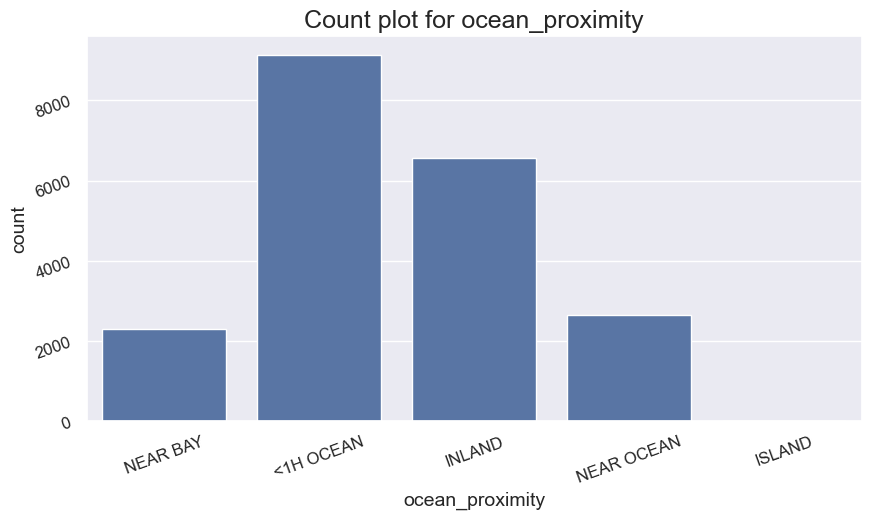

In [50]:
# Data visualization
# 1. COUNT PLOT FOR CATEGORICAL COLUMNS : To   count how many times each category appears in the dataset
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df , x = col)
    plt.title(f"Count plot for {col}")
    plt.xticks(rotation = 20)
    plt.yticks(rotation = 20)
    plt.show()

In [51]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


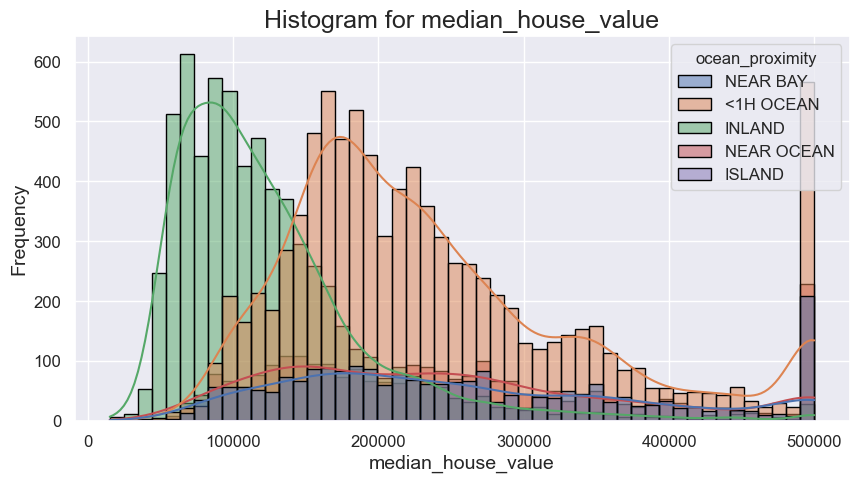

In [ ]:
# Histogram for target column: show the distribution[numerical data is distributed] of the target variable
plt.figure(figsize=(10, 5))
sns.histplot(data=df , x = target , bins = 50 , kde = True , color = "red" , edgecolor = "black", hue= 'ocean_proximity' )
plt.title(f"Histogram for {target}")
plt.xlabel(target)
plt.ylabel("Frequency")
plt.show()

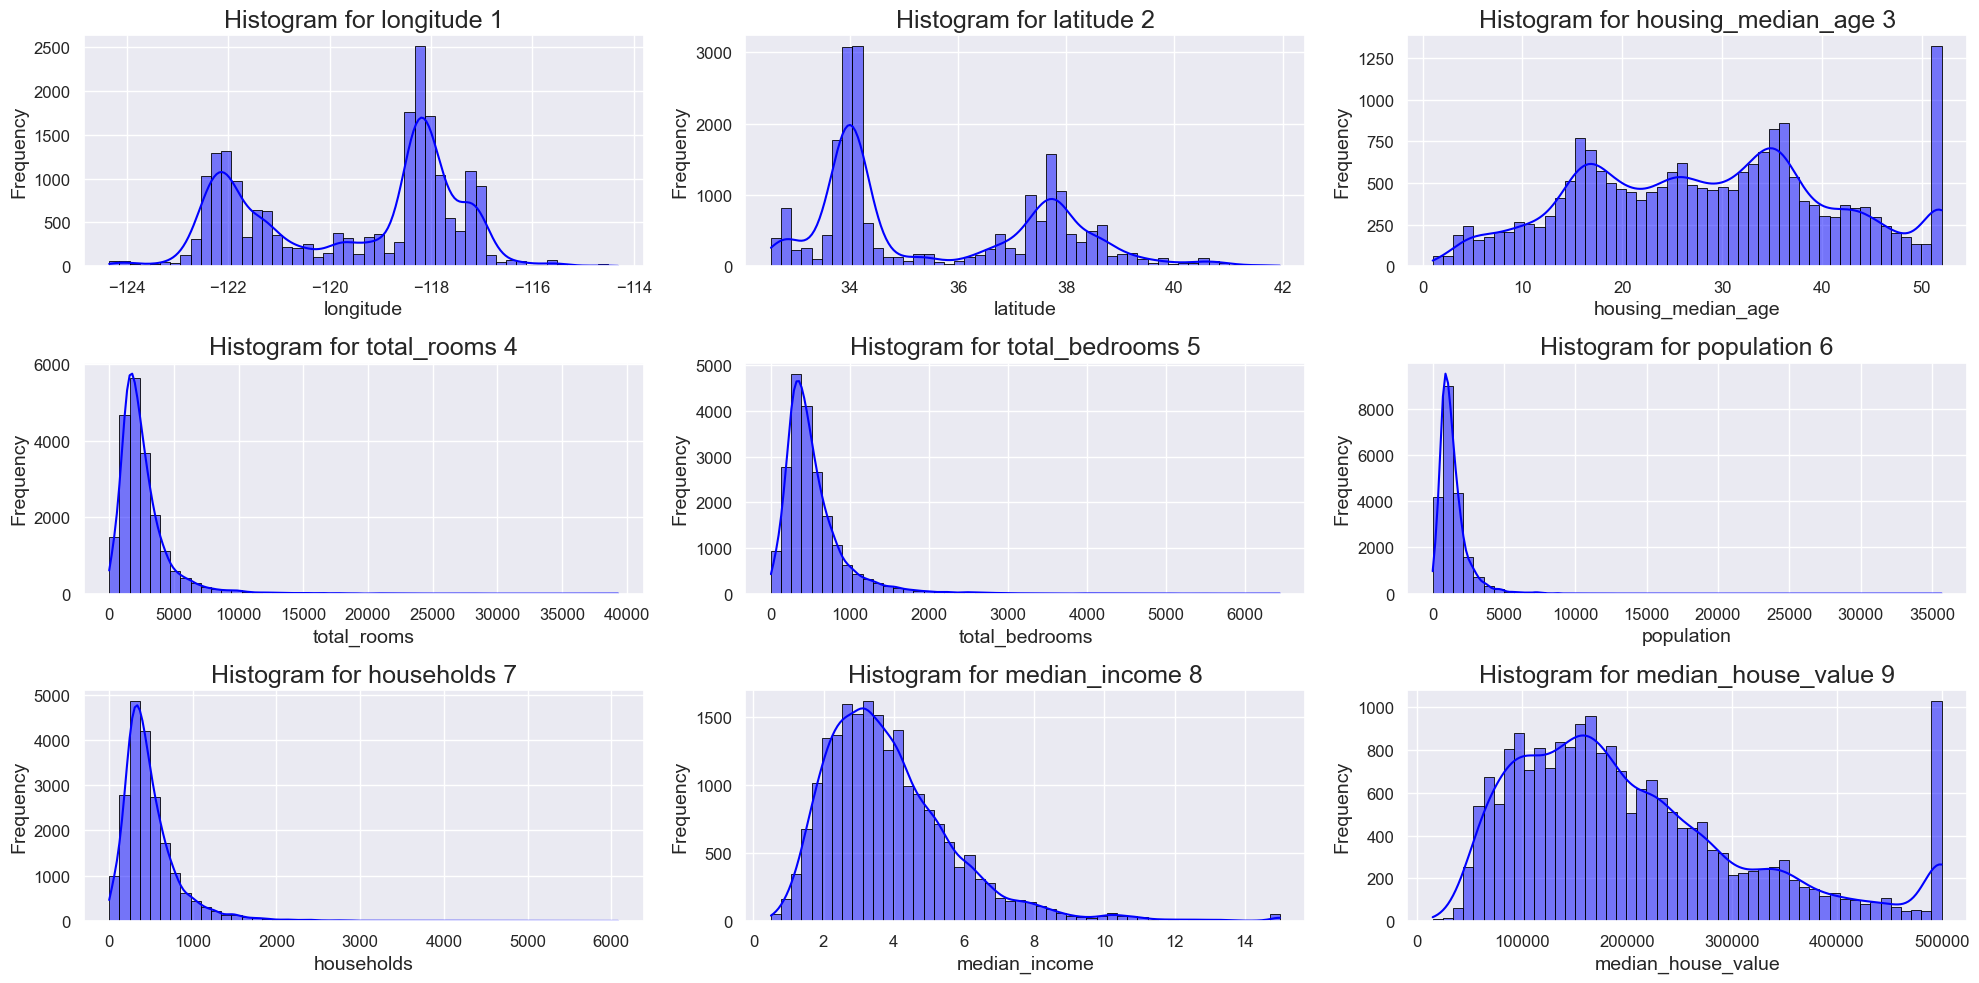

In [76]:
fig , axes = plt.subplots(3, 3 , figsize=(20, 10)) # grid of 3X3 == 9 numerical columns
axes = axes.flatten()  # making [[1,2,3] ,[4,5,6], [7,8,9]] to [1,2,3,4,5,6,7,8,9]

for i , col in enumerate(num_cols): # making the (0 to n - 1, col) pair for each numerical column where  n is the number of columns 
    sns.histplot(data=df , x = col , bins = 50 , kde = True , color = "blue" , edgecolor = "black", ax=axes[i])
    axes[i].set_title(f"Histogram for {col} {i+1}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


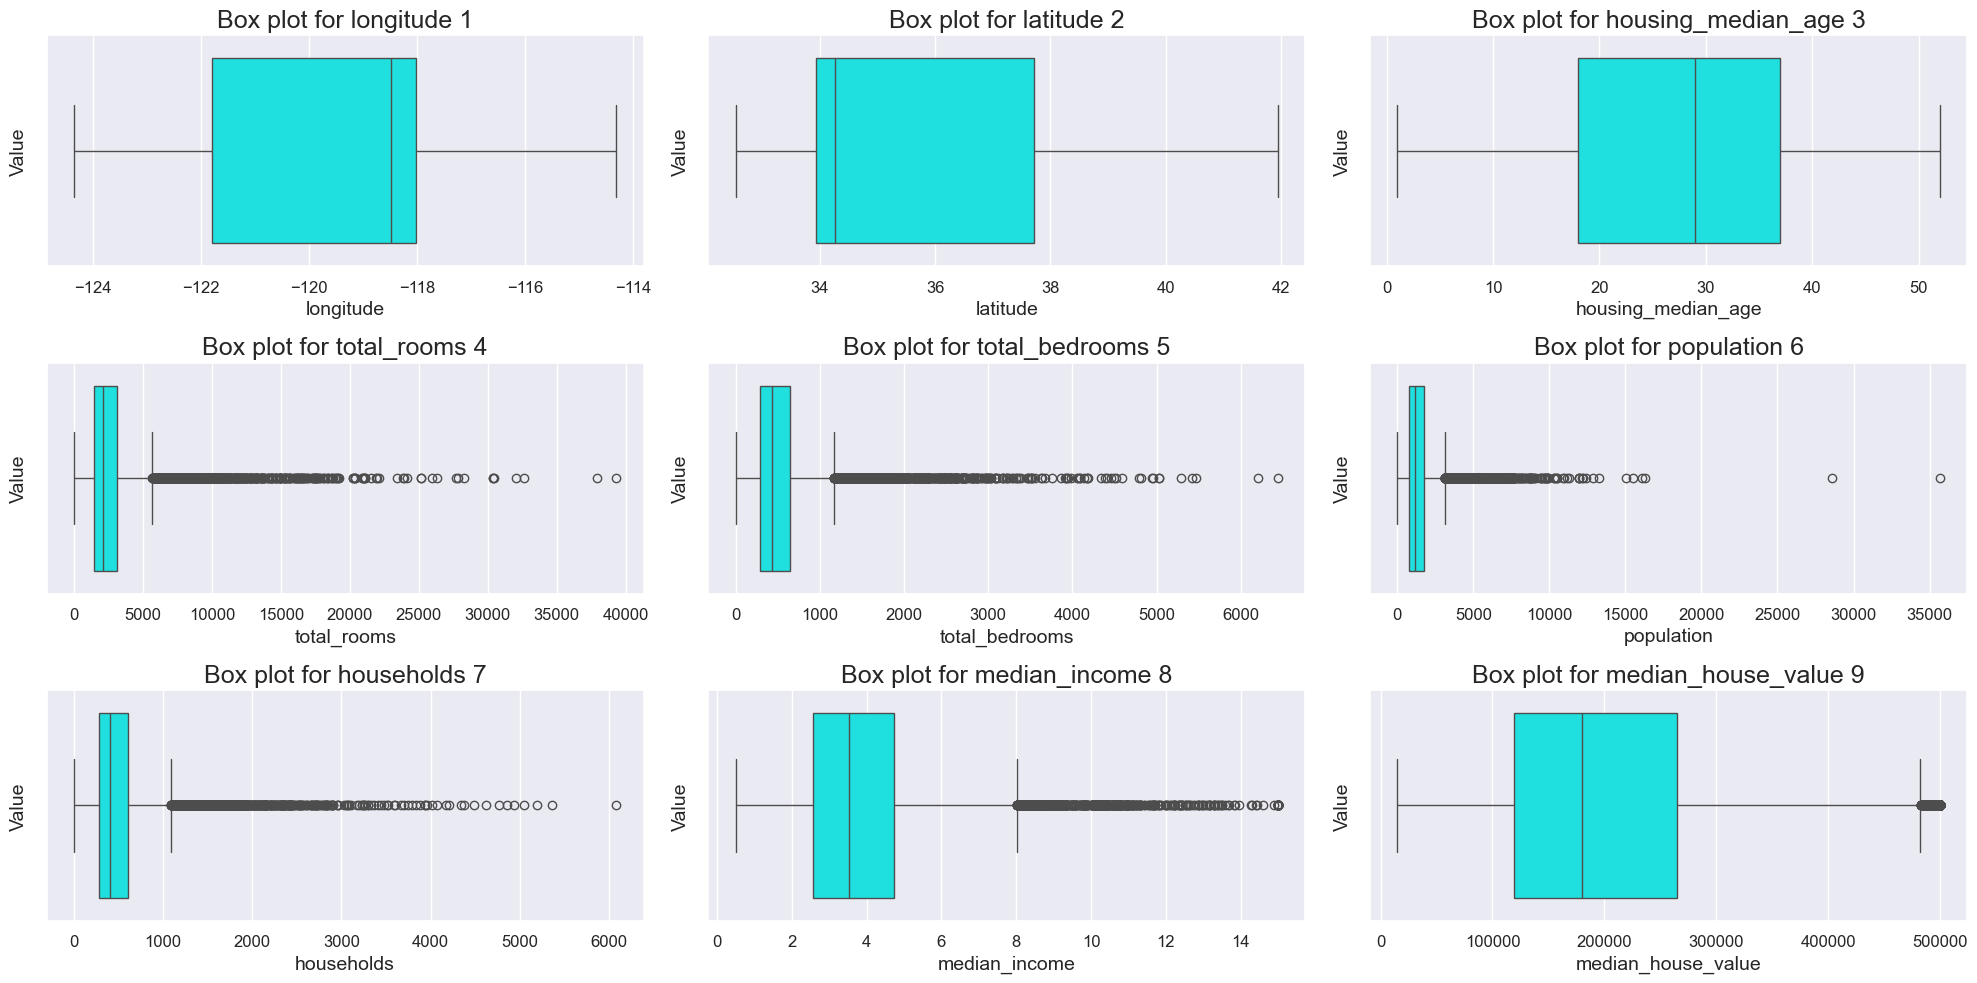

In [79]:
fig ,axes = plt.subplots(3, 3 , figsize=(20, 10)) # grid of 3X3 == 9 numerical columns
axes = axes.flatten() # making [[1,2,3] ,[4,5,6], [7,8,9]] to [1,2,3,4,5,6,7,8,9]
for i , col in enumerate(num_cols): # making the (0 to n - 1, col) pair for each numerical column where  n is the number of columns 
    sns.boxplot(data=df , x = col  , color = "cyan" , ax=axes[i])
    axes[i].set_title(f"Box plot for {col} {i+1}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Value")
plt.tight_layout()
plt.show()

In [85]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col} : {outliers.shape[0]}")

Outliers in longitude : 0
Outliers in latitude : 0
Outliers in housing_median_age : 0
Outliers in total_rooms : 1287
Outliers in total_bedrooms : 1271
Outliers in population : 1196
Outliers in households : 1220
Outliers in median_income : 681
Outliers in median_house_value : 1071


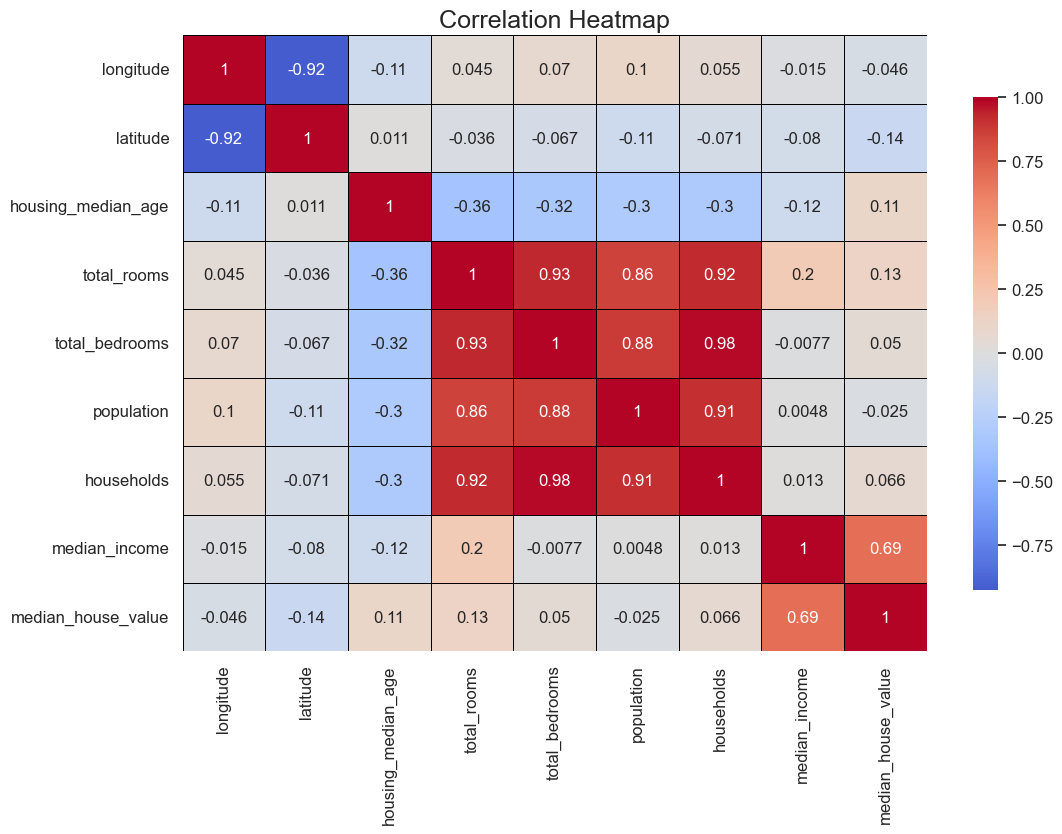

In [86]:
# Heatmap for correlation between numerical columns: used for 
# understanding the relationship between "numerical features and the target variable", 
# as well as among the features themselves.

# heatmap value is close to 1 : strong positive correlation
# heatmap value is close to -1 : strong negative correlation
# heatmap value is close to 0 : no correlation or weak correlation

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"shrink": 0.8},
    center=0
)
plt.title("Correlation Heatmap")
plt.show()



In [87]:
corr_with_target = df[num_cols].corr()[target].sort_values(ascending=False)
print("Correlation of numerical features with the target variable:")
print(corr_with_target)


Correlation of numerical features with the target variable:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


**Data preprocessing** 

In [93]:
# separate the features and target variable
x = df.drop(columns=[target])
y = df[target]


In [97]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(
    x ,
    y ,
    test_size=0.2 ,
    random_state=Random_state
)

# Here we are splitting the dataset into training and testing 
# sets with a test size of 20% and a random state for reproducibility.

In [103]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 9)
(4128, 9)
(16512,)
(4128,)


In [106]:
from sklearn.compose import ColumnTransformer

num = x_train.select_dtypes(include=np.number).columns.tolist()
cat = x_train.select_dtypes(include='object').columns.tolist()
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())

    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))

    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num),
        ('cat', categorical_transformer, cat)
    ]
)

**Baseline model**

In [110]:
baseline_pipe = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LinearRegression())
      
    ]
)

In [112]:
baseline_pipe.fit(x_train , y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [113]:
# Evaluate the model on the test set
train_baseline = baseline_pipe.predict(x_train)
test_baseline = baseline_pipe.predict(x_test)

In [120]:
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , r2_score
rmse_train = root_mean_squared_error(y_train , train_baseline)
mae_train = mean_absolute_error(y_train , train_baseline)
r2_train = r2_score(y_train , train_baseline)

print(f"Baseline Model Performance on Training Set:")
print(f"RMSE: {rmse_train:.3f}")
print(f"MAE: {mae_train:.3f}")
print(f"R^2 Score: {r2_train:.3f}")


Baseline Model Performance on Training Set:
RMSE: 68433.937
MAE: 49594.842
R^2 Score: 0.650


In [122]:
rmse_test = root_mean_squared_error(y_test , test_baseline)
mae_test = mean_absolute_error(y_test , test_baseline)
r2_test = r2_score(y_test , test_baseline)

print(f"Baseline Model Performance on Test Set:")
print(f"RMSE: {rmse_test:.3f}")
print(f"MAE: {mae_test:.3f}")
print(f"R^2 Score: {r2_test:.3f}")

Baseline Model Performance on Test Set:
RMSE: 70059.193
MAE: 50670.489
R^2 Score: 0.625


In [124]:
from sklearn.linear_model import Ridge , Lasso
from sklearn.ensemble import RandomForestRegressor , HistGradientBoostingRegressor
models = {
    'linear_regression': LinearRegression(),
    'Ridge': Ridge(random_state=Random_state),
    'Lasso': Lasso(random_state=Random_state , max_iter=10000),
    'random_forest': RandomForestRegressor(random_state=Random_state),
    'hist_gradient_boosting': HistGradientBoostingRegressor(random_state=Random_state)
}

In [125]:
from sklearn.model_selection import KFold
k = 5 
cv = KFold(n_splits=k , shuffle=True , random_state=Random_state)

In [127]:
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

In [129]:
from sklearn.model_selection import cross_validate
for name , model in models.items():
    pipe = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', model)
        ]
    )
    scores = cross_validate(pipe , x_train , y_train , cv=cv , scoring=scoring ,n_jobs=1)
    print(f"{name} Model Performance:")
    print(f"Average RMSE: {-scores['test_RMSE'].mean():.3f}")
    print(f"Average MAE: {-scores['test_MAE'].mean():.3f}")
    print(f"Average R^2 Score: {scores['test_R2'].mean():.3f}")
    print('---------------------------------------------')

linear_regression Model Performance:
Average RMSE: 68604.163
Average MAE: 49667.159
Average R^2 Score: 0.648
---------------------------------------------
Ridge Model Performance:
Average RMSE: 68595.617
Average MAE: 49664.331
Average R^2 Score: 0.648
---------------------------------------------
Lasso Model Performance:
Average RMSE: 68603.233
Average MAE: 49667.263
Average R^2 Score: 0.648
---------------------------------------------
random_forest Model Performance:
Average RMSE: 49445.286
Average MAE: 32328.533
Average R^2 Score: 0.817
---------------------------------------------
hist_gradient_boosting Model Performance:
Average RMSE: 48277.371
Average MAE: 32353.191
Average R^2 Score: 0.826
---------------------------------------------
